In [2]:
import pandas as pd
df=pd.read_csv("/content/adult.csv")
print(df)
print(df.head())
print(df.columns)
print(df.info())
print(df.shape)
print(df.count())
print(df.describe())

       Age          Workclass  Final Weight    Education  EducationNum  \
0       39          State-gov         77516    Bachelors            13   
1       50   Self-emp-not-inc         83311    Bachelors            13   
2       38            Private        215646      HS-grad             9   
3       53            Private        234721         11th             7   
4       28            Private        338409    Bachelors            13   
...    ...                ...           ...          ...           ...   
32556   27            Private        257302   Assoc-acdm            12   
32557   40            Private        154374      HS-grad             9   
32558   58            Private        151910      HS-grad             9   
32559   22            Private        201490      HS-grad             9   
32560   52       Self-emp-inc        287927      HS-grad             9   

            Marital Status          Occupation    Relationship    Race  \
0            Never-married        Adm

In [3]:
#1
print(df['Age'].mean())
#2
print(df.shape)
#3
print(df[['Age','Education','Income']].head(15))
#4
print(df['Workclass'].unique())
#5
print(df['Occupation'].nunique())
#6
print(df.isnull().sum())
#7
print(df['Hours per Week'].agg(['min','max','mean','median']))
#8
print(df['Education'].value_counts())
#9

#10
print(df[(df['Age']>=25)&(df['Age']>=40)&(df['Income']=='>50k')])
#11
print(df[['Capital Gain','capital loss']].agg(['min', 'max', 'mean', 'std']))
#12
print(df['Native Country'].value_counts().head(5))
#13
df[df["Education"].str.strip().isin(['Bachelors','Masters'])].groupby('Education')['Hours per Week'].mean()
#14


38.58164675532078
(32561, 15)
    Age      Education  Income
0    39      Bachelors   <=50K
1    50      Bachelors   <=50K
2    38        HS-grad   <=50K
3    53           11th   <=50K
4    28      Bachelors   <=50K
5    37        Masters   <=50K
6    49            9th   <=50K
7    52        HS-grad    >50K
8    31        Masters    >50K
9    42      Bachelors    >50K
10   37   Some-college    >50K
11   30      Bachelors    >50K
12   23      Bachelors   <=50K
13   32     Assoc-acdm   <=50K
14   40      Assoc-voc    >50K
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
15
Age               0
Workclass         0
Final Weight      0
Education         0
EducationNum      0
Marital Status    0
Occupation        0
Relationship      0
Race              0
Gender            0
Capital Gain      0
capital loss      0
Hours per Week    0
Native Country    0
Income            0
dtype: int64
min        1.000000
max       9

,Hours per Week
Education,
Bachelors,42.614006
Masters,43.836332


In [4]:
# statistical analysis
1#
print(df['Age'])
2#
print(df[['Age','Occupation','Education','Income']])
3#
df.iloc[1:11]
4#
df[['Age','Education']].iloc[10:21]
5#
df[df['Age']>50]
6#
df[df['Income']>'50k']
7#
print(df[(df['Age']>40)&(df['Hours per Week']>40)])
8#
print(df[df['Education'].isin([' Bachelors','Masters'])])


0        39
1        50
2        38
3        53
4        28
         ..
32556    27
32557    40
32558    58
32559    22
32560    52
Name: Age, Length: 32561, dtype: int64
       Age          Occupation    Education  Income
0       39        Adm-clerical    Bachelors   <=50K
1       50     Exec-managerial    Bachelors   <=50K
2       38   Handlers-cleaners      HS-grad   <=50K
3       53   Handlers-cleaners         11th   <=50K
4       28      Prof-specialty    Bachelors   <=50K
...    ...                 ...          ...     ...
32556   27        Tech-support   Assoc-acdm   <=50K
32557   40   Machine-op-inspct      HS-grad    >50K
32558   58        Adm-clerical      HS-grad   <=50K
32559   22        Adm-clerical      HS-grad   <=50K
32560   52     Exec-managerial      HS-grad    >50K

[32561 rows x 4 columns]
       Age          Workclass  Final Weight      Education  EducationNum  \
7       52   Self-emp-not-inc        209642        HS-grad             9   
19      43   Self-emp-not-i

In [5]:
#9
df['Age'].agg(['mean','min','max','median'])
#10
df[['Age','Hours per Week']].std()
#11
df.describe()
#12
print(df['Education'].value_counts(),
df['Education'].nunique())
#13
df['Income'].value_counts()
#17




Education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64 16


,count
Income,
<=50K,24720
>50K,7841


In [6]:
#cleaning
1#
df=df.replace(" ?",None)
df.isna().sum()
print(df.duplicated())
print(df.duplicated().sum())
print(df[df.duplicated(keep=False)])
2#
df.isna().sum()
4#
df['Workclass']=df['Workclass'].fillna('unknown')
print(df['Workclass'].isna().sum())

5#
df['Occupation']=df['Occupation'].fillna('Not Available')
6#
df['Age']=df['Age'].fillna(df['Age'].mean())
print(df['Age'])






0        False
1        False
2        False
3        False
4        False
         ...  
32556    False
32557    False
32558    False
32559    False
32560    False
Length: 32561, dtype: bool
24
       Age          Workclass  Final Weight      Education  EducationNum  \
2303    90            Private         52386   Some-college            10   
3917    19            Private        251579   Some-college            10   
4325    25            Private        308144      Bachelors            13   
4767    21            Private        250051   Some-college            10   
4881    25            Private        308144      Bachelors            13   
4940    38            Private        207202        HS-grad             9   
5104    90            Private         52386   Some-college            10   
5579    27            Private        255582        HS-grad             9   
5805    20            Private        107658   Some-college            10   
5842    25            Private        195994  

In [7]:
df['Age']=df['Age'].ffill() # forward fill
df['Native Country']=df['Native Country'].bfill() #backward fill
print(df['Native Country'])


0         United-States
1         United-States
2         United-States
3         United-States
4                  Cuba
              ...      
32556     United-States
32557     United-States
32558     United-States
32559     United-States
32560     United-States
Name: Native Country, Length: 32561, dtype: object


In [ ]:
# detecting outliers bounds(lower & upper)
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR=Q3-Q1
lower_bound=(Q1-1.5*IQR)
upper_bound=(Q3+1.5*IQR)
print(lower_bound)
print(upper_bound)
# Identify IQR outliers
iqr_outliers=df[(df['Age']<lower_bound)|(df['Age']>upper_bound)]
print("IQR Outliers:",len(iqr_outliers))
#------------------------------------------------------------
# 2. Z-score Method
from scipy.stats import zscore
df['Age_zscore']=zscore(df['Age'])
print(df['Age_zscore'])

z_outliers=df[
    df['Age_zscore'].abs()>3]
print("z-score Outliers:",len(z_outliers))

-2.0
78.0
IQR Outliers: 143
0        0.030671
1        0.837109
2       -0.042642
3        1.057047
4       -0.775768
           ...   
32556   -0.849080
32557    0.103983
32558    1.423610
32559   -1.215643
32560    0.983734
Name: Age_zscore, Length: 32561, dtype: float64
z-score Outliers: 121


In [ ]:
# winsorization
from scipy.stats.mstats import winsorize
df['Age_winsorized']=winsorize(
    df['Age'],
    limits=[0,0.5]
)
print(df.head())

   Age          Workclass  Final Weight   Education  EducationNum  \
0   37          State-gov         77516   Bachelors            13   
1   37   Self-emp-not-inc         83311   Bachelors            13   
2   37            Private        215646     HS-grad             9   
3   37            Private        234721        11th             7   
4   28            Private        338409   Bachelors            13   

        Marital Status          Occupation    Relationship    Race   Gender  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   Capital Gain  capital loss  Hours per Week  Native Country  Income  \
0          2174             0        

In [20]:
import matplotlib.pyplot as plt
plt.bar(df['Education'],df['EducationNum'],label="EducationNum")
plt.title("Education system")
plt.xlabel("Education")
plt.ylabel("years")
plt.show()

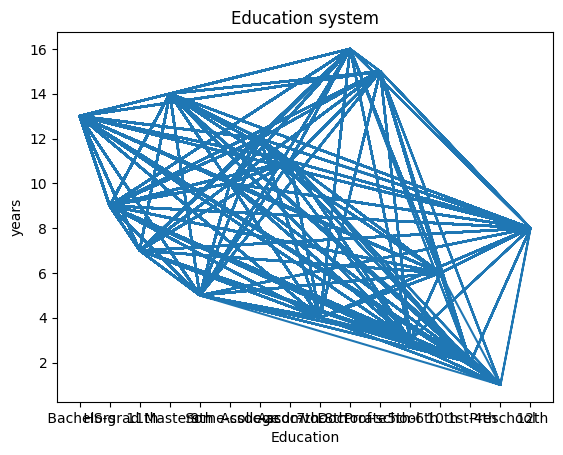

In [9]:
plt.plot(df['Education'],df['EducationNum'],label="EducationNum")
plt.title("Education system")
plt.xlabel("Education")
plt.ylabel("years")
plt.show()

In [10]:
!pip install autoviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 68.9 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.4.1
    Uninstalling xgboost-3.4.1:
      Successfully uninstalled xgboost-3.4.1


In [12]:
from autoviz.AutoViz_Class import AutoViz_Class
# pip install autoviz
AV=AutoViz_Class()
data=pd.read_csv('adult.csv')
AV.AutoViz(
    filename='adult.csv',
    sep=",",
    depVar='Income',
    dfte=data
)



Shape of your Data Set loaded: (32561, 15)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  6
    Number of String-Categorical Columns =  7
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  1
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    14 Predictors classified...
        No variables removed since no ID or low-information variables found in data set

################ Binary_Classification problem #####################
To fix these data qual

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
Age,int64,0.000000,0,17.000000,90.000000,Column has 142 outliers greater than upper bound (78.00) or lower than lower bound(-2.00). Cap them or remove them.
Workclass,object,0.000000,0,,,"2 rare categories: [' Without-pay', ' Never-worked']. Group them into a single category or drop the categories."
Final Weight,int64,0.000000,66,12285.000000,1484705.000000,Column has 993 outliers greater than upper bound (415742.00) or lower than lower bound(-60922.00). Cap them or remove them.
Education,object,0.000000,0,,,"2 rare categories: [' 1st-4th', ' Preschool']. Group them into a single category or drop the categories."
EducationNum,int64,0.000000,0,1.000000,16.000000,Column has 1193 outliers greater than upper bound (16.50) or lower than lower bound(4.50). Cap them or remove them.
Marital Status,object,0.000000,0,,,1 rare categories: [' Married-AF-spouse']. Group them into a single category or drop the categories.
Occupation,object,0.000000,0,,,"2 rare categories: [' Priv-house-serv', ' Armed-Forces']. Group them into a single category or drop the categories."
Relationship,object,0.000000,0,,,No issue
Race,object,0.000000,0,,,"2 rare categories: [' Amer-Indian-Eskimo', ' Other']. Group them into a single category or drop the categories."
Gender,object,0.000000,0,,,No issue


Total Number of Scatter Plots = 21
All Plots done
Time to run AutoViz = 13 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [13]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 27.3 MB/s eta 0:00:00


In [14]:
import pandas as pd
import sweetviz as sv
# pip install sweetviz
data=pd.read_csv('adult.csv')
report =sv.analyze(data)
report.show_html("sweetviz.report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz.report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [15]:
!pip install dtale

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.7/492.7 kB 24.8 MB/s eta 0:00:00


In [18]:
import pandas as pd
#pip install dtale
import dtale
data=pd.read_csv('adult.csv')
dtale.show(data)


http://d813fcaf9252:40000/dtale/main/2

In [22]:
!pip uninstall -y dtale

Found existing installation: dtale 3.22.0
Uninstalling dtale-3.22.0:
  Successfully uninstalled dtale-3.22.0


In [23]:
!pip uninstall -y autoviz

Found existing installation: autoviz 0.1.905
Uninstalling autoviz-0.1.905:
  Successfully uninstalled autoviz-0.1.905


In [24]:
!pip uninstall -y sweetviz

Found existing installation: sweetviz 2.3.3
Uninstalling sweetviz-2.3.3:
  Successfully uninstalled sweetviz-2.3.3


In [25]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00


In [26]:
import pandas as pd
from ydata_profiling import ProfileReport
data=pd.read_csv('adult.csv')
profile=ProfileReport(data,title="Adult dataset report")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:01<00:00, 12.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]